# Stage 2: individual dwelling-type model

This notebook preserves the validated Census–EOD harmonization and grouped model-selection design, evaluates the locked model once on the untouched Census test partition, refits it on all labeled Census dwellings, applies its direct probability output to the EOD, and draws one reproducible dwelling category per EOD dwelling. No spatial variables, quotas, or spatial adjustments enter the model.


In [1]:
from pathlib import Path
import json
from itertools import product

import matplotlib as mpl
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, Math, display
from joblib import dump, wrap_non_picklable_objects
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder

semilla = 2026
np.random.seed(semilla)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 160)
ruta_outputs = Path("..") / "outputs"
ruta_figuras = ruta_outputs / "figures"


## Validated inputs and harmonization

The unit of analysis is one dwelling. The seven approved predictors use the previously validated mappings. Census unknown targets remain excluded, factor_expansion is used for Census fitting and evaluation, ponderador is used only for EOD aggregation, and upm is used only for grouped splitting.


In [2]:
censo = pd.read_csv(ruta_outputs / "censo_viviendas_armonizado.csv", low_memory=False)
eod = pd.read_csv(ruta_outputs / "eod_viviendas_armonizado.csv", dtype={"folio_vivienda": "string", "ageb": "string", "centralidad": "string"}, low_memory=False)

mapa_municipio_censo = {39: "guadalajara", 44: "ixtlahuacan_de_los_membrillos", 51: "juanacatlan", 70: "el_salto", 97: "tlajomulco", 98: "tlaquepaque", 101: "tonala", 120: "zapopan", 124: "zapotlanejo"}
mapa_municipio_eod = {"Guadalajara": "guadalajara", "Ixtlahuacán de los Membrillos": "ixtlahuacan_de_los_membrillos", "Juanacatlán": "juanacatlan", "El Salto": "el_salto", "Tlajomulco": "tlajomulco", "Tlaquepaque": "tlaquepaque", "Tonalá": "tonala", "Zapopan": "zapopan", "Zapotlanejo": "zapotlanejo"}
mapa_tenencia_censo = {"Se paga renta": "rentada", "Es de un familiar o les prestan la vivienda": "prestada", "La ocupan en otra situación": "otra"}
mapa_deuda_propietaria = {"Está totalmente pagada": "propia", "Blanco por pase": "propia", "La están pagando": "hipotecada", "La dejaron de pagar": "hipotecada"}
mapa_tenencia_eod = {"Propia": "propia", "Hipotecada": "hipotecada", "Rentada": "rentada", "Prestada": "prestada", "Otros": "otra"}
mapa_disponibilidad = {"Sí": "si", "No": "no"}
mapa_conteo_vehiculo = {"0": "no", "1": "si", "2": "si", "3": "si", "4 o más": "si"}

censo_armonizado = censo.copy()
eod_armonizado = eod.copy()
censo_armonizado["municipio"] = censo["municipio"].map(mapa_municipio_censo).astype("string")
eod_armonizado["municipio"] = eod["municipio"].map(mapa_municipio_eod).astype("string")
censo_armonizado["personas_en_vivienda"] = pd.to_numeric(censo["numero_personas"], errors="coerce").clip(upper=10).astype("Int64")
eod_armonizado["personas_en_vivienda"] = pd.to_numeric(eod["personas_en_vivienda"].replace({"10 y +": 10}), errors="coerce").astype("Int64")
censo_armonizado["tenencia_vivienda"] = censo["tenencia"].map(mapa_tenencia_censo).astype("string")
mascara_propietaria = censo["tenencia"].eq("Vive la persona que es dueña o propietaria")
censo_armonizado.loc[mascara_propietaria, "tenencia_vivienda"] = censo.loc[mascara_propietaria, "deuda"].map(mapa_deuda_propietaria).astype("string")
eod_armonizado["tenencia_vivienda"] = eod["tenencia_vivienda"].map(mapa_tenencia_eod).astype("string")
censo_armonizado["tiene_auto_camioneta"] = censo["automovil_camioneta"].map(mapa_disponibilidad).astype("string")
censo_armonizado["tiene_moto"] = censo["motocicleta"].map(mapa_disponibilidad).astype("string")
censo_armonizado["tiene_bicicleta"] = censo["bicicleta"].map(mapa_disponibilidad).astype("string")
censo_armonizado["tiene_internet"] = censo["internet"].map(mapa_disponibilidad).astype("string")
eod_armonizado["tiene_auto_camioneta"] = eod["n_autos_camionetas"].map(mapa_conteo_vehiculo).astype("string")
eod_armonizado["tiene_moto"] = eod["n_motos"].map(mapa_conteo_vehiculo).astype("string")
eod_armonizado["tiene_bicicleta"] = eod["n_bicicletas"].map(mapa_conteo_vehiculo).astype("string")
eod_armonizado["tiene_internet"] = eod["tiene_internet"].map(mapa_disponibilidad).astype("string")

categorias_objetivo = ["casa_unica", "casa_compartida_duplex", "departamento", "otra_vivienda"]
predictores_finales = ["municipio", "personas_en_vivienda", "tenencia_vivienda", "tiene_auto_camioneta", "tiene_moto", "tiene_bicicleta", "tiene_internet"]


## Grouped outer partition

StratifiedGroupKFold approximately preserves the target distribution; it does not impose exact weighted proportions. Outer folds 1–4 form entrenamiento_seleccion, while fold 5 remains the untouched prueba_final.


In [3]:
registros_objetivo_desconocido = int(censo_armonizado["dwelling_type"].isna().sum())
censo_modelo = censo_armonizado.loc[censo_armonizado["dwelling_type"].notna()].reset_index(drop=True).copy()
asignador_externo = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=semilla)
censo_modelo["pliegue_externo"] = 0
for numero_pliegue, (_, indices_validacion) in enumerate(asignador_externo.split(censo_modelo[predictores_finales], censo_modelo["dwelling_type"], groups=censo_modelo["upm"]), start=1): censo_modelo.loc[indices_validacion, "pliegue_externo"] = numero_pliegue
censo_modelo["subconjunto"] = np.where(censo_modelo["pliegue_externo"].le(4), "entrenamiento_seleccion", "prueba_final")
datos_entrenamiento_seleccion = censo_modelo.loc[censo_modelo["subconjunto"].eq("entrenamiento_seleccion")].copy()
datos_prueba_final = censo_modelo.loc[censo_modelo["subconjunto"].eq("prueba_final")].copy()

def proporciones_ponderadas(datos, columna, peso):
    return np.array([datos.loc[datos[columna].eq(categoria), peso].sum() / datos[peso].sum() for categoria in categorias_objetivo])

tabla_distribucion_externa = pd.DataFrame({"categoria": categorias_objetivo, "censo_etiquetado": proporciones_ponderadas(censo_modelo, "dwelling_type", "factor_expansion"), "entrenamiento_seleccion": proporciones_ponderadas(datos_entrenamiento_seleccion, "dwelling_type", "factor_expansion"), "prueba_final": proporciones_ponderadas(datos_prueba_final, "dwelling_type", "factor_expansion")})
tabla_resumen_externo = censo_modelo.groupby("subconjunto").agg(registros=("dwelling_type", "size"), upm_unicos=("upm", "nunique")).reindex(["entrenamiento_seleccion", "prueba_final"]).reset_index()
upm_separados = set(datos_entrenamiento_seleccion["upm"]).isdisjoint(set(datos_prueba_final["upm"]))
display(Markdown(f"**Weighted Census target proportions.** The {registros_objetivo_desconocido:,} records with unknown target are excluded."))
display(tabla_distribucion_externa.round(6))
display(Markdown("**Outer-split record and group counts.**"))
display(tabla_resumen_externo)
display(Markdown(f"All upm groups remain separate between training/selection and final test: **{str(upm_separados).lower()}**."))


**Weighted Census target proportions.** The 44 records with unknown target are excluded.

,categoria,censo_etiquetado,entrenamiento_seleccion,prueba_final
0,casa_unica,0.743400,0.741760,0.749499
1,casa_compartida_duplex,0.135087,0.134944,0.135618
2,departamento,0.113250,0.114497,0.108613
3,otra_vivienda,0.008263,0.008799,0.006270


**Outer-split record and group counts.**

,subconjunto,registros,upm_unicos
0,entrenamiento_seleccion,31368,150
1,prueba_final,7826,36


All upm groups remain separate between training/selection and final test: **true**.

## Five-fold grouped model comparison

All candidates use the same five internal grouped folds. Preprocessing is fitted anew inside each training fold: training-only imputation, categorical one-hot encoding with unseen categories ignored, and numeric household size. Selection minimizes pooled factor_expansion-weighted multiclass log loss and requires improvement over the weighted prior-only baseline.


In [4]:
@wrap_non_picklable_objects
def normalizar_faltantes(datos):
    return datos.astype(object).where(pd.notna(datos), np.nan)

predictores_categoricos = ["municipio", "tenencia_vivienda", "tiene_auto_camioneta", "tiene_moto", "tiene_bicicleta", "tiene_internet"]
predictores_numericos = ["personas_en_vivienda"]
normalizador_faltantes = FunctionTransformer(normalizar_faltantes, validate=False)
preprocesamiento_categorico = Pipeline([("normalizacion_faltantes", normalizador_faltantes), ("imputacion", SimpleImputer(strategy="most_frequent")), ("codificacion", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])
preprocesamiento_numerico = Pipeline([("normalizacion_faltantes", normalizador_faltantes), ("imputacion", SimpleImputer(strategy="median"))])
preprocesador = ColumnTransformer([("categoricos", preprocesamiento_categorico, predictores_categoricos), ("numericos", preprocesamiento_numerico, predictores_numericos)])

candidatos = [{"id_configuracion": "referencia_prior_ponderada", "modelo": "referencia_prior_ponderada", "hiperparametros": {}, "estimador": None}]
for c in [0.1, 1.0, 10.0]: candidatos.append({"id_configuracion": f"regresion_logistica_multinomial_c_{str(c).replace('.', '_')}", "modelo": "regresion_logistica_multinomial", "hiperparametros": {"C": c, "solver": "lbfgs", "max_iter": 1000, "random_state": semilla}, "estimador": LogisticRegression(C=c, solver="lbfgs", max_iter=1000, random_state=semilla)})
for learning_rate, max_leaf_nodes, min_samples_leaf in product([0.05, 0.1], [7, 15], [20, 50]): candidatos.append({"id_configuracion": f"gradiente_histograma_lr_{str(learning_rate).replace('.', '_')}_hojas_{max_leaf_nodes}_min_{min_samples_leaf}", "modelo": "gradiente_histograma", "hiperparametros": {"learning_rate": learning_rate, "max_leaf_nodes": max_leaf_nodes, "min_samples_leaf": min_samples_leaf, "l2_regularization": 1.0, "max_iter": 200, "random_state": semilla}, "estimador": HistGradientBoostingClassifier(learning_rate=learning_rate, max_leaf_nodes=max_leaf_nodes, min_samples_leaf=min_samples_leaf, l2_regularization=1.0, max_iter=200, random_state=semilla)})
for max_depth, min_samples_leaf in product([10, 15], [20, 50]): candidatos.append({"id_configuracion": f"bosque_aleatorio_profundidad_{max_depth}_min_{min_samples_leaf}", "modelo": "bosque_aleatorio", "hiperparametros": {"n_estimators": 400, "max_depth": max_depth, "min_samples_leaf": min_samples_leaf, "max_features": "sqrt", "class_weight": None, "n_jobs": -1, "random_state": semilla}, "estimador": RandomForestClassifier(n_estimators=400, max_depth=max_depth, min_samples_leaf=min_samples_leaf, max_features="sqrt", class_weight=None, n_jobs=-1, random_state=semilla)})

asignador_interno = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=semilla)
datos_entrenamiento_seleccion["pliegue_interno"] = 0
for numero_pliegue, (_, posiciones_validacion) in enumerate(asignador_interno.split(datos_entrenamiento_seleccion[predictores_finales], datos_entrenamiento_seleccion["dwelling_type"], groups=datos_entrenamiento_seleccion["upm"]), start=1): datos_entrenamiento_seleccion.iloc[posiciones_validacion, datos_entrenamiento_seleccion.columns.get_loc("pliegue_interno")] = numero_pliegue


In [5]:
def calcular_log_loss_ponderada(objetivo, probabilidades, pesos):
    indices_objetivo = np.array([categorias_objetivo.index(categoria) for categoria in objetivo])
    probabilidades_seguras = np.clip(probabilidades, np.finfo(float).eps, 1)
    probabilidades_seguras = probabilidades_seguras / probabilidades_seguras.sum(axis=1, keepdims=True)
    return np.average(-np.log(probabilidades_seguras[np.arange(len(objetivo)), indices_objetivo]), weights=pesos)

resultados_candidatos = []
metricas_por_pliegue = []
for candidato in candidatos:
    probabilidades_oof = np.zeros((len(datos_entrenamiento_seleccion), len(categorias_objetivo)))
    for pliegue_validacion in [1, 2, 3, 4, 5]:
        mascara_validacion = datos_entrenamiento_seleccion["pliegue_interno"].eq(pliegue_validacion).to_numpy()
        datos_entrenamiento_interno = datos_entrenamiento_seleccion.loc[~mascara_validacion]
        datos_validacion_interna = datos_entrenamiento_seleccion.loc[mascara_validacion]
        pesos_entrenamiento_interno = datos_entrenamiento_interno["factor_expansion"].to_numpy()
        pesos_validacion_interna = datos_validacion_interna["factor_expansion"].to_numpy()
        if candidato["estimador"] is None:
            prevalencias_entrenamiento = proporciones_ponderadas(datos_entrenamiento_interno, "dwelling_type", "factor_expansion")
            probabilidades_validacion = np.tile(prevalencias_entrenamiento, (len(datos_validacion_interna), 1))
        else:
            tuberia = Pipeline([("preprocesamiento", clone(preprocesador)), ("modelo", clone(candidato["estimador"]))])
            tuberia.fit(datos_entrenamiento_interno[predictores_finales], datos_entrenamiento_interno["dwelling_type"], modelo__sample_weight=pesos_entrenamiento_interno)
            probabilidades_modelo = tuberia.predict_proba(datos_validacion_interna[predictores_finales])
            clases_modelo = tuberia.named_steps["modelo"].classes_
            probabilidades_validacion = probabilidades_modelo[:, [np.where(clases_modelo == categoria)[0][0] for categoria in categorias_objetivo]]
        probabilidades_oof[mascara_validacion] = probabilidades_validacion
        log_loss_pliegue = calcular_log_loss_ponderada(datos_validacion_interna["dwelling_type"], probabilidades_validacion, pesos_validacion_interna)
        metricas_por_pliegue.append([candidato["id_configuracion"], pliegue_validacion, log_loss_pliegue])
    log_loss_oof = calcular_log_loss_ponderada(datos_entrenamiento_seleccion["dwelling_type"], probabilidades_oof, datos_entrenamiento_seleccion["factor_expansion"].to_numpy())
    resultados_candidatos.append([candidato["id_configuracion"], candidato["modelo"], json.dumps(candidato["hiperparametros"], ensure_ascii=False, sort_keys=True, separators=(",", ":")), log_loss_oof])

resultados_comparacion = pd.DataFrame(resultados_candidatos, columns=["id_configuracion", "modelo", "hiperparametros", "log_loss_ponderada"])
metricas_por_pliegue = pd.DataFrame(metricas_por_pliegue, columns=["id_configuracion", "pliegue_validacion", "log_loss_ponderada"])
log_loss_referencia_cv = resultados_comparacion.loc[resultados_comparacion["id_configuracion"].eq("referencia_prior_ponderada"), "log_loss_ponderada"].iloc[0]
candidatos_elegibles = resultados_comparacion.loc[resultados_comparacion["id_configuracion"].ne("referencia_prior_ponderada") & resultados_comparacion["log_loss_ponderada"].lt(log_loss_referencia_cv)].copy()
if len(candidatos_elegibles):
    perdida_minima = candidatos_elegibles["log_loss_ponderada"].min()
    id_seleccionado = candidatos_elegibles.loc[np.isclose(candidatos_elegibles["log_loss_ponderada"], perdida_minima, rtol=0, atol=1e-12)].sort_values("id_configuracion").iloc[0]["id_configuracion"]
else:
    id_seleccionado = "referencia_prior_ponderada"
candidato_seleccionado = next(candidato for candidato in candidatos if candidato["id_configuracion"] == id_seleccionado)
resultados_comparacion["seleccionado"] = resultados_comparacion["id_configuracion"].eq(id_seleccionado)
resultados_ordenados = resultados_comparacion.sort_values(["log_loss_ponderada", "id_configuracion"]).reset_index(drop=True)
resultados_ordenados.insert(0, "orden", resultados_ordenados.index + 1)
parametros_seleccionados = json.dumps(candidato_seleccionado["hiperparametros"], ensure_ascii=False, sort_keys=True, separators=(",", ":"))
metricas_seleccionadas_por_pliegue = metricas_por_pliegue.loc[metricas_por_pliegue["id_configuracion"].eq(id_seleccionado), ["pliegue_validacion", "log_loss_ponderada"]].copy()
display(Markdown("**Ordered weighted out-of-fold log-loss comparison.**"))
display(resultados_ordenados[["orden", "modelo", "hiperparametros", "log_loss_ponderada", "seleccionado"]].round({"log_loss_ponderada": 6}))
display(Markdown(f"**Selected model:** {candidato_seleccionado['modelo']}  \n**Exact hyperparameters:** {parametros_seleccionados}"))
display(Markdown("**Selected model weighted log loss by internal validation fold.**"))
display(metricas_seleccionadas_por_pliegue.round(6))


**Ordered weighted out-of-fold log-loss comparison.**

,orden,modelo,hiperparametros,log_loss_ponderada,seleccionado
0,1,gradiente_histograma,"{""l2_regularization"":1.0,""learning_rate"":0.05,""max_iter"":200,""max_leaf_nodes"":7,""min_samples_leaf"":50,""random_state"":2026}",0.709591,True
1,2,gradiente_histograma,"{""l2_regularization"":1.0,""learning_rate"":0.1,""max_iter"":200,""max_leaf_nodes"":7,""min_samples_leaf"":50,""random_state"":2026}",0.709682,False
2,3,gradiente_histograma,"{""l2_regularization"":1.0,""learning_rate"":0.05,""max_iter"":200,""max_leaf_nodes"":7,""min_samples_leaf"":20,""random_state"":2026}",0.709921,False
3,4,bosque_aleatorio,"{""class_weight"":null,""max_depth"":10,""max_features"":""sqrt"",""min_samples_leaf"":20,""n_estimators"":400,""n_jobs"":-1,""random_state"":2026}",0.710398,False
4,5,gradiente_histograma,"{""l2_regularization"":1.0,""learning_rate"":0.1,""max_iter"":200,""max_leaf_nodes"":7,""min_samples_leaf"":20,""random_state"":2026}",0.710439,False
5,6,bosque_aleatorio,"{""class_weight"":null,""max_depth"":15,""max_features"":""sqrt"",""min_samples_leaf"":50,""n_estimators"":400,""n_jobs"":-1,""random_state"":2026}",0.711151,False
6,7,bosque_aleatorio,"{""class_weight"":null,""max_depth"":10,""max_features"":""sqrt"",""min_samples_leaf"":50,""n_estimators"":400,""n_jobs"":-1,""random_state"":2026}",0.711452,False
7,8,gradiente_histograma,"{""l2_regularization"":1.0,""learning_rate"":0.05,""max_iter"":200,""max_leaf_nodes"":15,""min_samples_leaf"":50,""random_state"":2026}",0.711687,False
8,9,bosque_aleatorio,"{""class_weight"":null,""max_depth"":15,""max_features"":""sqrt"",""min_samples_leaf"":20,""n_estimators"":400,""n_jobs"":-1,""random_state"":2026}",0.712020,False
9,10,gradiente_histograma,"{""l2_regularization"":1.0,""learning_rate"":0.05,""max_iter"":200,""max_leaf_nodes"":15,""min_samples_leaf"":20,""random_state"":2026}",0.712171,False


**Selected model:** gradiente_histograma  
**Exact hyperparameters:** {"l2_regularization":1.0,"learning_rate":0.05,"max_iter":200,"max_leaf_nodes":7,"min_samples_leaf":50,"random_state":2026}

**Selected model weighted log loss by internal validation fold.**

,pliegue_validacion,log_loss_ponderada
25,1,0.717330
26,2,0.738463
27,3,0.698639
28,4,0.660704
29,5,0.730386


## Untouched Census final test

The locked configuration is fitted once on all training/selection records and compared with the weighted prior-only baseline on the untouched final test. Balanced accuracy describes hard argmax classification, while log loss evaluates the complete probability vector and determines model selection.


In [6]:
pesos_entrenamiento_seleccion = datos_entrenamiento_seleccion["factor_expansion"].to_numpy()
pesos_prueba_final = datos_prueba_final["factor_expansion"].to_numpy()
prevalencias_referencia_final = proporciones_ponderadas(datos_entrenamiento_seleccion, "dwelling_type", "factor_expansion")
probabilidades_referencia_final = np.tile(prevalencias_referencia_final, (len(datos_prueba_final), 1))
if candidato_seleccionado["estimador"] is None:
    modelo_entrenamiento_seleccion = None
    probabilidades_modelo_final = probabilidades_referencia_final.copy()
else:
    modelo_entrenamiento_seleccion = Pipeline([("preprocesamiento", clone(preprocesador)), ("modelo", clone(candidato_seleccionado["estimador"]))])
    modelo_entrenamiento_seleccion.fit(datos_entrenamiento_seleccion[predictores_finales], datos_entrenamiento_seleccion["dwelling_type"], modelo__sample_weight=pesos_entrenamiento_seleccion)
    probabilidades_modelo_original = modelo_entrenamiento_seleccion.predict_proba(datos_prueba_final[predictores_finales])
    clases_modelo_final = modelo_entrenamiento_seleccion.named_steps["modelo"].classes_
    probabilidades_modelo_final = probabilidades_modelo_original[:, [np.where(clases_modelo_final == categoria)[0][0] for categoria in categorias_objetivo]]

log_loss_referencia_final = calcular_log_loss_ponderada(datos_prueba_final["dwelling_type"], probabilidades_referencia_final, pesos_prueba_final)
log_loss_modelo_final = calcular_log_loss_ponderada(datos_prueba_final["dwelling_type"], probabilidades_modelo_final, pesos_prueba_final)
prediccion_referencia_final = np.array(categorias_objetivo)[np.argmax(probabilidades_referencia_final, axis=1)]
prediccion_modelo_final = np.array(categorias_objetivo)[np.argmax(probabilidades_modelo_final, axis=1)]
exactitud_balanceada_referencia = balanced_accuracy_score(datos_prueba_final["dwelling_type"], prediccion_referencia_final, sample_weight=pesos_prueba_final)
exactitud_balanceada_modelo = balanced_accuracy_score(datos_prueba_final["dwelling_type"], prediccion_modelo_final, sample_weight=pesos_prueba_final)
validacion_final_aprobada = log_loss_modelo_final < log_loss_referencia_final
comparacion_prueba_final = pd.DataFrame([["referencia_prior_ponderada", log_loss_referencia_final, exactitud_balanceada_referencia], [candidato_seleccionado["modelo"], log_loss_modelo_final, exactitud_balanceada_modelo]], columns=["procedimiento", "log_loss_ponderada", "balanced_accuracy_ponderada"])
display(Markdown("**Final-test comparison.**"))
display(comparacion_prueba_final.round(6))
display(Markdown("Balanced accuracy describes hard argmax classification; weighted log loss evaluates the complete probability vectors and determines model selection."))


**Final-test comparison.**

,procedimiento,log_loss_ponderada,balanced_accuracy_ponderada
0,referencia_prior_ponderada,0.760589,0.250000
1,gradiente_histograma,0.679022,0.261994


Balanced accuracy describes hard argmax classification; weighted log loss evaluates the complete probability vectors and determines model selection.

## Production refit, EOD categorical draw, and outputs

Production proceeds only when the selected model improves final-test weighted log loss over the prior-only baseline. The locked pipeline is then refitted on all labeled Census dwellings, and its direct predict_proba output is applied to every harmonized EOD dwelling. A seeded categorical draw uses each dwelling’s own four-probability vector in stable folio_vivienda order.


**EOD output verification.**

,filas_eod,folios_vivienda_unicos,json_y_vectores_validos,una_categoria_aprobada_por_vivienda
0,17901,17901,True,True


**Weighted dwelling-type distributions.**

,categoria,censo_observado_ponderado,eod_esperado_ponderado,eod_muestreado_ponderado
0,casa_unica,0.743400,0.771005,0.771533
1,casa_compartida_duplex,0.135087,0.124269,0.124375
2,departamento,0.113250,0.098388,0.097424
3,otra_vivienda,0.008263,0.006338,0.006668


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

The first distance is a descriptive population difference; the second measures how closely this one draw reproduced its own expected EOD distribution. Neither distance validates predictions against observed EOD dwelling types.

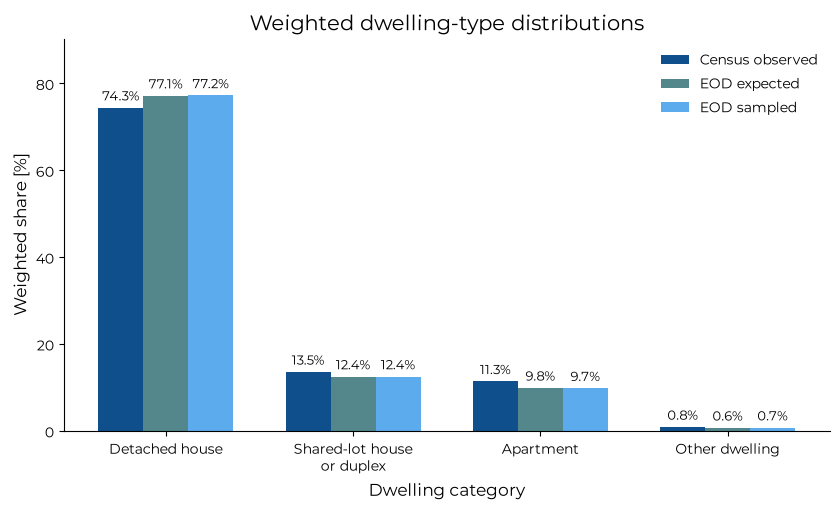

**Saved model:** /Users/sebastiangutierrezbernal/Desktop/Tec/Ciudades para el futuro/Proyecto Transporte GDL/dwelling_type/outputs/modelo_dwelling_type_individual.joblib  
**Saved CSV:** /Users/sebastiangutierrezbernal/Desktop/Tec/Ciudades para el futuro/Proyecto Transporte GDL/dwelling_type/outputs/eod_probabilidades_individuales.csv  
**Saved PNG:** /Users/sebastiangutierrezbernal/Desktop/Tec/Ciudades para el futuro/Proyecto Transporte GDL/dwelling_type/outputs/figures/distribucion_dwelling_type_censo_eod.png  
**Saved PDF:** /Users/sebastiangutierrezbernal/Desktop/Tec/Ciudades para el futuro/Proyecto Transporte GDL/dwelling_type/outputs/figures/distribucion_dwelling_type_censo_eod.pdf

In [7]:
if validacion_final_aprobada:
    modelo_produccion = Pipeline([("preprocesamiento", clone(preprocesador)), ("modelo", clone(candidato_seleccionado["estimador"]))])
    modelo_produccion.fit(censo_modelo[predictores_finales], censo_modelo["dwelling_type"], modelo__sample_weight=censo_modelo["factor_expansion"].to_numpy())
    eod_ordenado = eod_armonizado.sort_values("folio_vivienda", kind="mergesort").reset_index(drop=True)
    probabilidades_eod_modelo = modelo_produccion.predict_proba(eod_ordenado[predictores_finales])
    clases_modelo_produccion = modelo_produccion.named_steps["modelo"].classes_
    probabilidades_eod = probabilidades_eod_modelo[:, [np.where(clases_modelo_produccion == categoria)[0][0] for categoria in categorias_objetivo]]
    columnas_probabilidad = ["probabilidad_casa_unica", "probabilidad_casa_compartida_duplex", "probabilidad_departamento", "probabilidad_otra_vivienda"]
    eod_resultados = eod_ordenado[["folio_vivienda", "ponderador", "municipio", "ageb", "centralidad"]].copy()
    eod_resultados[columnas_probabilidad] = probabilidades_eod
    generador = np.random.default_rng(semilla)
    eod_resultados["dwelling_type"] = [generador.choice(categorias_objetivo, p=probabilidades) for probabilidades in probabilidades_eod]
    eod_resultados["dwelling_type_source"] = "cpv2020_modelo_individual_muestreo"
    eod_resultados["probabilidad_tipo_vivienda"] = [json.dumps({categoria: float(probabilidad) for categoria, probabilidad in zip(categorias_objetivo, probabilidades)}, ensure_ascii=False, separators=(",", ":")) for probabilidades in probabilidades_eod]
    eod_probabilidades_individuales = eod_resultados[["folio_vivienda", "ponderador", "municipio", "ageb", "centralidad", "probabilidad_tipo_vivienda", "dwelling_type", "dwelling_type_source"]].rename(columns={"dwelling_type": "muestreo_tipo_vivienda", "dwelling_type_source": "fuente_tipo_vivienda"})
    mapeos_eod = {"municipio": mapa_municipio_eod, "tenencia_vivienda": mapa_tenencia_eod, "conteo_vehiculo": mapa_conteo_vehiculo, "disponibilidad": mapa_disponibilidad, "personas_en_vivienda": {"10 y +": 10}}
    paquete_modelo = {"modelo": modelo_produccion, "clases": categorias_objetivo, "predictores": predictores_finales, "semilla": semilla, "mapeos_eod": mapeos_eod}
    ruta_modelo = ruta_outputs / "modelo_dwelling_type_individual.joblib"
    ruta_probabilidades = ruta_outputs / "eod_probabilidades_individuales.csv"
    dump(paquete_modelo, ruta_modelo)
    eod_probabilidades_individuales.to_csv(ruta_probabilidades, index=False)

    datos_guardados = pd.read_csv(ruta_probabilidades, dtype={"folio_vivienda": "string", "ageb": "string", "centralidad": "string"}, low_memory=False)
    probabilidades_json = datos_guardados["probabilidad_tipo_vivienda"].map(json.loads)
    json_probabilidades_validas = all(list(diccionario.keys()) == categorias_objetivo and np.isfinite(list(diccionario.values())).all() and np.all(np.array(list(diccionario.values())) >= 0) and np.all(np.array(list(diccionario.values())) <= 1) and np.isclose(sum(diccionario.values()), 1.0) for diccionario in probabilidades_json)
    categorias_asignadas_validas = datos_guardados["muestreo_tipo_vivienda"].notna().all() and datos_guardados["muestreo_tipo_vivienda"].isin(categorias_objetivo).all()
    resumen_salida = pd.DataFrame([[len(datos_guardados), datos_guardados["folio_vivienda"].nunique(), json_probabilidades_validas, categorias_asignadas_validas]], columns=["filas_eod", "folios_vivienda_unicos", "json_y_vectores_validos", "una_categoria_aprobada_por_vivienda"])
    display(Markdown("**EOD output verification.**"))
    display(resumen_salida)

    distribucion_censo = proporciones_ponderadas(censo_modelo, "dwelling_type", "factor_expansion")
    distribucion_eod_esperada = np.array([np.average(probabilidades_eod[:, indice], weights=eod_resultados["ponderador"]) for indice in range(len(categorias_objetivo))])
    distribucion_eod_muestreada = np.array([eod_resultados.loc[eod_resultados["dwelling_type"].eq(categoria), "ponderador"].sum() / eod_resultados["ponderador"].sum() for categoria in categorias_objetivo])
    tabla_distribuciones = pd.DataFrame({"categoria": categorias_objetivo, "censo_observado_ponderado": distribucion_censo, "eod_esperado_ponderado": distribucion_eod_esperada, "eod_muestreado_ponderado": distribucion_eod_muestreada})
    distancia_tv_censo_eod = 0.5 * np.abs(distribucion_censo - distribucion_eod_esperada).sum()
    distancia_tv_esperada_muestreada = 0.5 * np.abs(distribucion_eod_esperada - distribucion_eod_muestreada).sum()
    display(Markdown("**Weighted dwelling-type distributions.**"))
    display(tabla_distribuciones.round(6))
    display(Math(r"D_{\mathrm{TV}}(p,q)=\frac{1}{2}\sum_{k=1}^{4}|p_k-q_k|"))
    display(Math(rf"D_{{\mathrm{{TV}}}}(\mathrm{{Census}},\mathrm{{EOD\ expected}})={distancia_tv_censo_eod:.6f}"))
    display(Math(rf"D_{{\mathrm{{TV}}}}(\mathrm{{EOD\ expected}},\mathrm{{EOD\ sampled}})={distancia_tv_esperada_muestreada:.6f}"))
    display(Markdown("The first distance is a descriptive population difference; the second measures how closely this one draw reproduced its own expected EOD distribution. Neither distance validates predictions against observed EOD dwelling types."))

    rutas_fuentes = list((Path.home() / "Library/Fonts").glob("Montserrat*.ttf")) + list(Path("/Library/Fonts").glob("Montserrat*.ttf"))
    for ruta_fuente in rutas_fuentes: fm.fontManager.addfont(str(ruta_fuente))
    colores = [(0.06, 0.31, 0.55), (0.33, 0.53, 0.55), (0.36, 0.67, 0.93)]
    etiquetas_categoria = ["Detached house", "Shared-lot house\nor duplex", "Apartment", "Other dwelling"]
    etiquetas_serie = ["Census observed", "EOD expected", "EOD sampled"]
    valores_figura = np.column_stack([distribucion_censo, distribucion_eod_esperada, distribucion_eod_muestreada]) * 100
    ruta_figuras.mkdir(parents=True, exist_ok=True)
    ruta_png = ruta_figuras / "distribucion_dwelling_type_censo_eod.png"
    ruta_pdf = ruta_figuras / "distribucion_dwelling_type_censo_eod.pdf"
    with mpl.rc_context({"text.usetex": False, "font.family": "sans-serif", "font.sans-serif": ["Montserrat"]}):
        fig, ax = plt.subplots(figsize=(8.5, 5.2))
        posiciones = np.arange(len(categorias_objetivo))
        ancho = 0.24
        for indice_serie, (etiqueta, color) in enumerate(zip(etiquetas_serie, colores)):
            barras = ax.bar(posiciones + (indice_serie - 1) * ancho, valores_figura[:, indice_serie], width=ancho, color=color, label=etiqueta)
            ax.bar_label(barras, fmt="%.1f%%", padding=3, fontsize=9)
        ax.set_title("Weighted dwelling-type distributions", fontsize=15)
        ax.set_xlabel("Dwelling category", fontsize=12)
        ax.set_ylabel("Weighted share [%]", fontsize=12)
        ax.set_xticks(posiciones)
        ax.set_xticklabels(etiquetas_categoria)
        ax.tick_params(axis="x", rotation=0, labelsize=10)
        ax.tick_params(axis="y", labelsize=10)
        ax.legend(frameon=False, fontsize=10)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.set_ylim(0, valores_figura.max() * 1.17)
        plt.tight_layout()
        fig.savefig(ruta_png, dpi=600, bbox_inches="tight", transparent=True)
        fig.savefig(ruta_pdf, bbox_inches="tight", transparent=True)
        plt.show()

    display(Markdown(f"**Saved model:** {ruta_modelo.resolve()}  \n**Saved CSV:** {ruta_probabilidades.resolve()}  \n**Saved PNG:** {ruta_png.resolve()}  \n**Saved PDF:** {ruta_pdf.resolve()}"))
else:
    display(Markdown("**Production stopped:** the selected model did not improve final-test weighted log loss over the prior-only baseline, so the existing model bundle and CSV were not replaced."))
